In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/edu_growth_cleaned.csv")

In [4]:
df.shape

(46500, 102)

In [5]:
subjects = ["coa","maths4","dstl","ds","python","cyber"]
labs = ["ds","python","coa","cyber"]

In [6]:
marks_cols = {
    "coa": ["coa_st1_marks","coa_st2_marks","coa_put_marks","coa_unit_1_marks","coa_unit_2_marks","coa_unit_3_marks","coa_unit_4_marks","coa_unit_5_marks"],
    "maths4": ["maths4_st1_marks","maths4_st2_marks","maths4_put_marks","maths4_unit_1_marks","maths4_unit_2_marks","maths4_unit_3_marks","maths4_unit_4_marks","maths4_unit_5_marks"],
    "dstl": ["dstl_st1_marks","dstl_st2_marks","dstl_put_marks","dstl_unit_1_marks","dstl_unit_2_marks","dstl_unit_3_marks","dstl_unit_4_marks","dstl_unit_5_marks"],
    "ds": ["ds_st1_marks","ds_st2_marks","ds_put_marks","ds_unit_1_marks","ds_unit_2_marks","ds_unit_3_marks","ds_unit_4_marks","ds_unit_5_marks"],
    "python": ["python_st1_marks","python_st2_marks","python_put_marks","python_unit_1_marks","python_unit_2_marks","python_unit_3_marks","python_unit_4_marks","python_unit_5_marks"],
    "cyber": ["cyber_st1_marks","cyber_st2_marks","cyber_put_marks","cyber_unit_1_marks","cyber_unit_2_marks","cyber_unit_3_marks","cyber_unit_4_marks","cyber_unit_5_marks"]
}
marks_cols["coa"]


['coa_st1_marks',
 'coa_st2_marks',
 'coa_put_marks',
 'coa_unit_1_marks',
 'coa_unit_2_marks',
 'coa_unit_3_marks',
 'coa_unit_4_marks',
 'coa_unit_5_marks']

In [7]:
lab_score_cols = {
    "ds": ["lab_ds_execution_score","lab_ds_viva_score"],
    "python": ["lab_python_execution_score","lab_python_viva_score"],
    "coa": ["lab_coa_execution_score","lab_coa_viva_score"],
    "cyber": ["lab_cyber_execution_score","lab_cyber_viva_score"]
}
lab_score_cols["ds"]


['lab_ds_execution_score', 'lab_ds_viva_score']

In [8]:
attendance_cols = ["coa_attendance_pct","maths4_attendance_pct","dstl_attendance_pct","ds_attendance_pct","python_attendance_pct","cyber_attendance_pct","lab_ds_attendance_pct","lab_python_attendance_pct","lab_coa_attendance_pct","lab_cyber_attendance_pct","overall_attendance_pct"]
len(attendance_cols)


11

In [9]:
other_cols = ["coa_assignment_score","maths4_assignment_score","dstl_assignment_score","ds_assignment_score","python_assignment_score","cyber_assignment_score","coa_assignment_delay_hours","maths4_assignment_delay_hours","dstl_assignment_delay_hours","ds_assignment_delay_hours","python_assignment_delay_hours","cyber_assignment_delay_hours","coa_quiz_score","maths4_quiz_score","dstl_quiz_score","ds_quiz_score","python_quiz_score","cyber_quiz_score","lab_ds_submission_delay_hours","lab_python_submission_delay_hours","lab_coa_submission_delay_hours","lab_cyber_submission_delay_hours","previous_cgpa"]
len(other_cols)


23

In [10]:
all_features = []
all_features += marks_cols["coa"]
all_features += marks_cols["maths4"]
all_features += marks_cols["dstl"]
all_features += marks_cols["ds"]
all_features += marks_cols["python"]
all_features += marks_cols["cyber"]
all_features += lab_score_cols["ds"]
all_features += lab_score_cols["python"]
all_features += lab_score_cols["coa"]
all_features += lab_score_cols["cyber"]
all_features += attendance_cols + other_cols
len(all_features)


90

In [11]:
df[all_features] = df[all_features].apply(pd.to_numeric,errors="coerce")
print("Missing values:",df[all_features].isna().sum().sum())

Missing values: 0


In [12]:
st1_cols = ["coa_st1_marks","maths4_st1_marks","dstl_st1_marks","ds_st1_marks","python_st1_marks","cyber_st1_marks"]
st2_cols = ["coa_st2_marks","maths4_st2_marks","dstl_st2_marks","ds_st2_marks","python_st2_marks","cyber_st2_marks"]
put_cols = ["coa_put_marks","maths4_put_marks","dstl_put_marks","ds_put_marks","python_put_marks","cyber_put_marks"]
lab_exec_cols = ["lab_ds_execution_score","lab_python_execution_score","lab_coa_execution_score","lab_cyber_execution_score"]
lab_viva_cols = ["lab_ds_viva_score","lab_python_viva_score","lab_coa_viva_score","lab_cyber_viva_score"]
max_marks = {
    "st1": df[st1_cols].max().max(),
    "st2": df[st2_cols].max().max(),
    "put": df[put_cols].max().max(),
    "lab_exec": df[lab_exec_cols].max().max(),
    "lab_viva": df[lab_viva_cols].max().max()
}
max_marks


{'st1': np.float64(30.0),
 'st2': np.float64(30.0),
 'put': np.float64(100.0),
 'lab_exec': np.float64(50.0),
 'lab_viva': np.float64(30.0)}

In [13]:

for s in subjects:
    st1 = s + "_st1_marks"
    st2 = s + "_st2_marks"
    put = s + "_put_marks"
    st1_pct = df[st1] / max_marks["st1"] * 100
    st2_pct = df[st2] / max_marks["st2"] * 100
    put_pct = df[put] / max_marks["put"] * 100
    df[s + "_marks_pct"] = (st1_pct + st2_pct + put_pct) / 3

df[["coa_marks_pct","maths4_marks_pct","dstl_marks_pct","ds_marks_pct","python_marks_pct","cyber_marks_pct"]].describe()


C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\2287717033.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[s + "_marks_pct"] = (st1_pct + st2_pct + put_pct) / 3
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\2287717033.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[s + "_marks_pct"] = (st1_pct + st2_pct + put_pct) / 3
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\2287717033.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

,coa_marks_pct,maths4_marks_pct,dstl_marks_pct,ds_marks_pct,python_marks_pct,cyber_marks_pct
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,67.425463,67.440673,67.468835,67.504033,67.494639,67.566228
std,19.143950,19.138185,19.189882,19.103375,19.221316,19.168324
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.011111,54.000000,54.022222,54.055556,53.966667,54.041667
50%,68.877778,68.955556,69.000000,69.077778,68.922222,69.066667
75%,82.600000,82.466667,82.577778,82.500000,82.691667,82.722222
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [14]:
weak_limit = 65
for s in subjects:
    df[s + "_risk"] = (df[s + "_marks_pct"] < weak_limit).astype(int)

subject_label_cols = ["coa_risk","maths4_risk","dstl_risk","ds_risk","python_risk","cyber_risk"]
df[subject_label_cols].mean() * 100


C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\1010475665.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[s + "_risk"] = (df[s + "_marks_pct"] < weak_limit).astype(int)
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\1010475665.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[s + "_risk"] = (df[s + "_marks_pct"] < weak_limit).astype(int)
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\1010475665.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

coa_risk       43.169892
maths4_risk    42.780645
dstl_risk      42.911828
ds_risk        42.662366
python_risk    42.980645
cyber_risk     42.619355
dtype: float64

In [15]:
lab_groups = {"ds":["lab_ds_execution_score","lab_ds_viva_score"],"python":["lab_python_execution_score","lab_python_viva_score"],"coa":["lab_coa_execution_score","lab_coa_viva_score"],"cyber":["lab_cyber_execution_score","lab_cyber_viva_score"]}
for l in labs:
    exec_pct = df[lab_groups[l][0]] / max_marks["lab_exec"] * 100
    viva_pct = df[lab_groups[l][1]] / max_marks["lab_viva"] * 100
    df["lab_" + l + "_pct"] = (exec_pct + viva_pct) / 2
    df["lab_" + l + "_risk"] = (df["lab_" + l + "_pct"] < weak_limit).astype(int)

lab_label_cols = ["lab_ds_risk","lab_python_risk","lab_coa_risk","lab_cyber_risk"]
df[lab_label_cols].mean() * 100


C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\828865762.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lab_" + l + "_pct"] = (exec_pct + viva_pct) / 2
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\828865762.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lab_" + l + "_risk"] = (df["lab_" + l + "_pct"] < weak_limit).astype(int)
C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\828865762.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

lab_ds_risk        41.382796
lab_python_risk    41.094624
lab_coa_risk       41.245161
lab_cyber_risk     41.761290
dtype: float64

In [16]:
attendance_limit = 60
df["attendance_risk"] = (df["overall_attendance_pct"] < attendance_limit).astype(int)
df["attendance_risk"].mean() * 100

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_24908\3505430557.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["attendance_risk"] = (df["overall_attendance_pct"] < attendance_limit).astype(int)


np.float64(30.789247311827957)

In [17]:
risk_label_cols = subject_label_cols + lab_label_cols + ["attendance_risk"]
label_summary = (df[risk_label_cols].mean() * 100).round(2)
label_summary

coa_risk           43.17
maths4_risk        42.78
dstl_risk          42.91
ds_risk            42.66
python_risk        42.98
cyber_risk         42.62
lab_ds_risk        41.38
lab_python_risk    41.09
lab_coa_risk       41.25
lab_cyber_risk     41.76
attendance_risk    30.79
dtype: float64

In [18]:
targets = {
    "coa_risk": marks_cols["coa"],
    "maths4_risk": marks_cols["maths4"],
    "dstl_risk": marks_cols["dstl"],
    "ds_risk": marks_cols["ds"],
    "python_risk": marks_cols["python"],
    "cyber_risk": marks_cols["cyber"],
    "lab_ds_risk": lab_score_cols["ds"],
    "lab_python_risk": lab_score_cols["python"],
    "lab_coa_risk": lab_score_cols["coa"],
    "lab_cyber_risk": lab_score_cols["cyber"],
    "attendance_risk": attendance_cols
}
len(targets.keys())


11

In [19]:

target = "ds_risk"
leakage_cols = set(targets[target]) | {target}
features = [c for c in all_features if c not in leakage_cols]
X = df[features]
y = df[target]
print("Features:",len(features))
print("Risk students (%):",y.mean() * 100)


Features: 82
Risk students (%): 42.66236559139785


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape
X_test.shape


(9300, 82)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced")
lr_model.fit(X_train,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [23]:
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

In [24]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
print("Logistic Regression Results")
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred,zero_division=0))
print("Recall:",recall_score(y_test,lr_pred,zero_division=0))
print("F1 Score:",f1_score(y_test,lr_pred,zero_division=0))
print("ROC-AUC:",roc_auc_score(y_test,lr_prob))

Logistic Regression Results
Accuracy: 0.7993548387096774
Precision: 0.748314606741573
Recall: 0.777431906614786
F1 Score: 0.7625954198473283
ROC-AUC: 0.8636257159497343


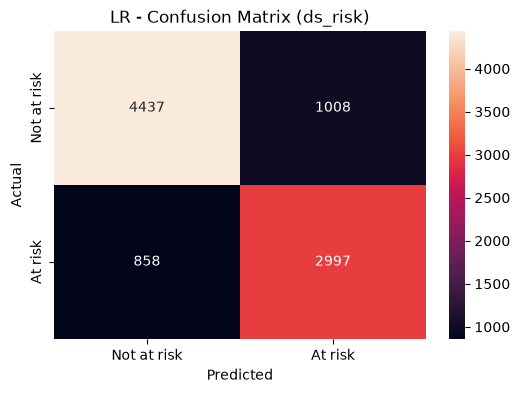

In [25]:
cm = confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Not at risk","At risk"],yticklabels=["Not at risk","At risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LR - Confusion Matrix (ds_risk)")
plt.show()

In [26]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb_model.fit(X_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
def train_risk_model(df,features,target_name):
    X = df[features]
    y = df[target_name]
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    lr_model = LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced")
    lr_model.fit(X_train,y_train)
    lr_prob = lr_model.predict_proba(X_test)[:,1]
    xgb_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42)
    xgb_model.fit(X_train,y_train)
    xgb_prob = xgb_model.predict_proba(X_test)[:,1]
    lr_auc = roc_auc_score(y_test,lr_prob)
    xgb_auc = roc_auc_score(y_test,xgb_prob)
    if xgb_auc >= lr_auc:
        best_name = "XGBoost"
        best_model = xgb_model
        best_prob = xgb_prob
    else:
        best_name = "Logistic Regression"
        best_model = lr_model
        best_prob = lr_prob
    best_threshold = 0.5
    best_f1 = 0
    for threshold in np.arange(0.1,0.91,0.05):
        pred = (best_prob >= threshold).astype(int)
        f1 = f1_score(y_test,pred,zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = round(float(threshold),2)
    final_pred = (best_prob >= best_threshold).astype(int)
    return {"model":best_model,"model_name":best_name,"scaler":scaler,"features":features,"threshold":best_threshold,"lr_auc":lr_auc,"xgb_auc":xgb_auc,"accuracy":accuracy_score(y_test,final_pred),"precision":precision_score(y_test,final_pred,zero_division=0),"recall":recall_score(y_test,final_pred,zero_division=0),"f1":f1_score(y_test,final_pred,zero_division=0)}


In [28]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
for threshold in [0.3, 0.4, 0.5, 0.6]:
    pred = (xgb_prob >= threshold).astype(int)
    print(
        "Threshold:", threshold,
        "| Precision:", round(precision_score(y_test, pred, zero_division=0), 3),
        "| Recall:", round(recall_score(y_test, pred, zero_division=0), 3),
        "| F1:", round(f1_score(y_test, pred, zero_division=0), 3)
    )

Threshold: 0.3 | Precision: 0.751 | Recall: 0.801 | F1: 0.775
Threshold: 0.4 | Precision: 0.815 | Recall: 0.754 | F1: 0.783
Threshold: 0.5 | Precision: 0.853 | Recall: 0.707 | F1: 0.773
Threshold: 0.6 | Precision: 0.889 | Recall: 0.664 | F1: 0.76


In [29]:
results = {}
target_name = "ds_risk"
results[target_name] = train_risk_model(df,features,target_name)

In [30]:
summary_rows = []
for target_name,r in results.items():
    summary_rows.append({"target":target_name,"best_model":r["model_name"],"threshold":r["threshold"],"LR_auc":round(r["lr_auc"],3),"XGB_auc":round(r["xgb_auc"],3),"accuracy":round(r["accuracy"],3),"precision":round(r["precision"],3),"recall":round(r["recall"],3),"f1":round(r["f1"],3)})

model_summary = pd.DataFrame(summary_rows)
model_summary


,target,best_model,threshold,LR_auc,XGB_auc,accuracy,precision,recall,f1
0,ds_risk,XGBoost,0.35,0.865,0.877,0.821,0.795,0.78,0.788


In [34]:
id_cols=['roll_no']

In [38]:
risk_output = df[id_cols].copy()

for target_name in targets:
    if target_name in results:
        r = results[target_name]
        X_all = r["scaler"].transform(df[r["features"]])
        prob = r["model"].predict_proba(X_all)[:,1]
        pred = (prob >= r["threshold"]).astype(int)
    else:
        pred = df[target_name].values
    risk_output[target_name + "_pred"] = pred

risk_output.sample(5)


,roll_no,coa_risk_pred,maths4_risk_pred,dstl_risk_pred,ds_risk_pred,python_risk_pred,cyber_risk_pred,lab_ds_risk_pred,lab_python_risk_pred,lab_coa_risk_pred,lab_cyber_risk_pred,attendance_risk_pred
10834,210029041427,0,1,1,1,1,1,0,1,0,1,1
12487,210029034784,1,1,1,0,1,0,0,0,0,0,0
28330,210029040264,0,0,0,0,0,0,0,0,0,0,1
40644,210029046630,0,0,0,0,0,0,0,0,0,0,0
35753,210029020184,1,1,0,1,1,1,1,1,1,1,1


In [42]:
subject_pred_cols = ["coa_risk_pred","maths4_risk_pred","dstl_risk_pred","ds_risk_pred","python_risk_pred","cyber_risk_pred"]
lab_pred_cols = ["lab_ds_risk_pred","lab_python_risk_pred","lab_coa_risk_pred","lab_cyber_risk_pred"]
risk_output["weak_subject_count"] = risk_output[subject_pred_cols].sum(axis=1)
risk_output["weak_lab_count"] = risk_output[lab_pred_cols].sum(axis=1)
risk_output["total_risk_count"] = risk_output["weak_subject_count"] + risk_output["weak_lab_count"] + risk_output["attendance_risk_pred"]


In [43]:
risk_output["risk_subjects"] = ""
risk_output.loc[risk_output["coa_risk_pred"] == 1,"risk_subjects"] += "coa, "
risk_output.loc[risk_output["maths4_risk_pred"] == 1,"risk_subjects"] += "maths4, "
risk_output.loc[risk_output["dstl_risk_pred"] == 1,"risk_subjects"] += "dstl, "
risk_output.loc[risk_output["ds_risk_pred"] == 1,"risk_subjects"] += "ds, "
risk_output.loc[risk_output["python_risk_pred"] == 1,"risk_subjects"] += "python, "
risk_output.loc[risk_output["cyber_risk_pred"] == 1,"risk_subjects"] += "cyber, "
risk_output["risk_labs"] = ""
risk_output.loc[risk_output["lab_ds_risk_pred"] == 1,"risk_labs"] += "ds, "
risk_output.loc[risk_output["lab_python_risk_pred"] == 1,"risk_labs"] += "python, "
risk_output.loc[risk_output["lab_coa_risk_pred"] == 1,"risk_labs"] += "coa, "
risk_output.loc[risk_output["lab_cyber_risk_pred"] == 1,"risk_labs"] += "cyber, "
risk_output["risk_subjects"] = risk_output["risk_subjects"].str.rstrip(", ")
risk_output["risk_labs"] = risk_output["risk_labs"].str.rstrip(", ")
risk_output[id_cols + ["weak_subject_count","weak_lab_count","attendance_risk_pred","risk_subjects","risk_labs"]].head(10)


,roll_no,weak_subject_count,weak_lab_count,attendance_risk_pred,risk_subjects,risk_labs
0,210029053348,6,4,1,"coa, maths4, dstl, ds, python, cyber","ds, python, coa, cyber"
1,210029035828,4,2,0,"coa, dstl, ds, python","ds, cyber"
2,210029039616,0,0,1,,
3,210029036528,0,0,0,,
4,210029010644,3,0,0,"maths4, ds, python",
5,210029041588,0,1,0,,ds
6,210029015843,5,4,0,"coa, maths4, dstl, ds, cyber","ds, python, coa, cyber"
7,210029033819,0,0,1,,
8,210029012530,3,2,0,"coa, dstl, ds","ds, cyber"
9,210029034296,4,1,0,"coa, maths4, ds, python",ds


In [44]:
risk_output["weak_subject_count"].value_counts().sort_index()


weak_subject_count
0    10027
1    10302
2     6249
3     4071
4     3555
5     3783
6     8513
Name: count, dtype: int64

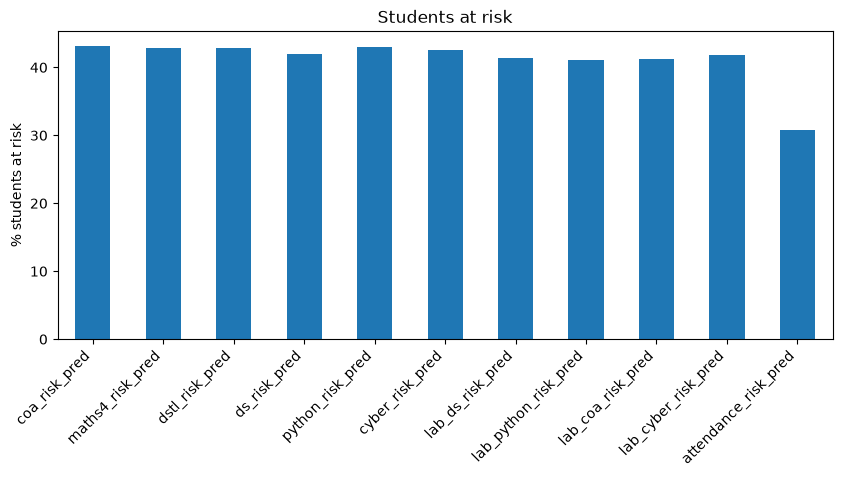

In [45]:
pred_cols = ["coa_risk_pred","maths4_risk_pred","dstl_risk_pred","ds_risk_pred","python_risk_pred","cyber_risk_pred","lab_ds_risk_pred","lab_python_risk_pred","lab_coa_risk_pred","lab_cyber_risk_pred","attendance_risk_pred"]
(risk_output[pred_cols].mean() * 100).plot(kind="bar",figsize=(10,4))
plt.ylabel("% students at risk")
plt.title("Students at risk")
plt.xticks(rotation=45,ha="right")
plt.show()


In [40]:
def student_report(i):
    row = risk_output.loc[i]
    print("Student:", row[id_cols].to_dict() if id_cols else i)
    print("-" * 45)
    
    subject_names = ["coa", "maths4", "dstl", "ds", "python", "cyber"]
    for s in subject_names:
        status = "RISK" if row[s + "_risk_pred"] == 1 else "OK"
        print(f"Subject {s:8}: {status}")
        
    print("-" * 45)
    lab_names = ["ds", "python", "coa", "cyber"]
    for l in lab_names:
        status = "RISK" if row["lab_" + l + "_risk_pred"] == 1 else "OK"
        print(f"Lab {l:12}: {status}")
        
    print("-" * 45)
    status = "RISK" if row["attendance_risk_pred"] == 1 else "OK"
    print(f"Attendance  : {status}")

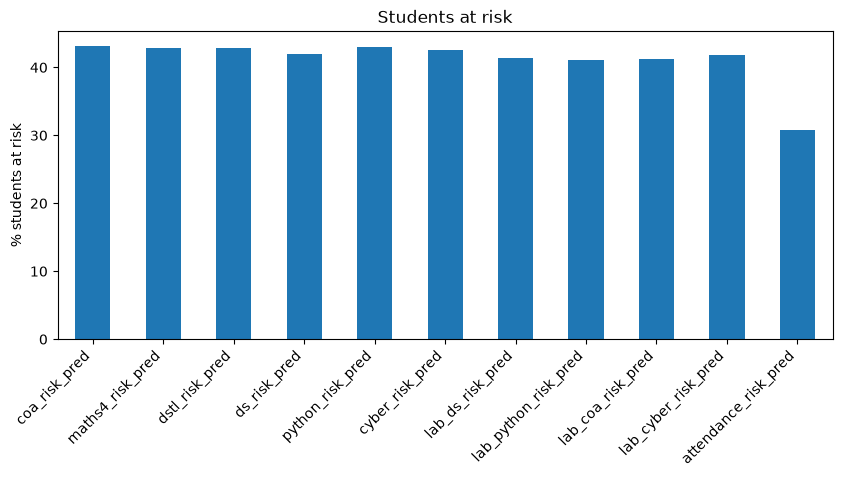

In [46]:
pred_cols = subject_pred_cols + lab_pred_cols + ["attendance_risk_pred"]
(risk_output[pred_cols].mean() * 100).plot(kind="bar",figsize=(10,4))
plt.ylabel("% students at risk")
plt.title("Students at risk")
plt.xticks(rotation=45,ha="right")
plt.show()

In [48]:
import joblib
risk_output.to_csv("../artifacts/risk_output.csv",index=False)
joblib.dump(results,"../artifacts/risk_models.pkl")


['../artifacts/risk_models.pkl']

In [49]:
student_report(1)

Student: {'roll_no': 210029035828}
---------------------------------------------
Subject coa     : RISK
Subject maths4  : OK
Subject dstl    : RISK
Subject ds      : RISK
Subject python  : RISK
Subject cyber   : OK
---------------------------------------------
Lab ds          : RISK
Lab python      : OK
Lab coa         : OK
Lab cyber       : RISK
---------------------------------------------
Attendance  : OK


In [50]:
worst_student = risk_output["total_risk_count"].idxmax()
student_report(worst_student)

Student: {'roll_no': 210029053348}
---------------------------------------------
Subject coa     : RISK
Subject maths4  : RISK
Subject dstl    : RISK
Subject ds      : RISK
Subject python  : RISK
Subject cyber   : RISK
---------------------------------------------
Lab ds          : RISK
Lab python      : RISK
Lab coa         : RISK
Lab cyber       : RISK
---------------------------------------------
Attendance  : RISK
